# Notebook 10 — Artist Style: Whose Voice Is Most Recognizable?

The premise: artists with a **distinctive lyrical style** should be identifiable from their lyrics alone, while artists who write in a generic register should be confusable with others. We'll quantify this for the most-charting artists in our dataset.

**Tasks:**
1. Find the artists with enough songs to analyze (≥6 charting hits)
2. Train a classifier to predict artist from lyrics
3. Measure each artist's per-class F1 score — high F1 = distinctive
4. Examine confusion patterns — which artists get mistaken for each other?
5. Find each artist's most-characteristic words (vs. the rest of the corpus)
6. Visualize artists in semantic space using embeddings

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
df = pd.read_parquet(PROCESSED_DIR / "songs_with_topics.parquet")
print(f"Total songs: {len(df):,}")
print(f"Unique artists: {df['artist'].nunique():,}")

Total songs: 6,538
Unique artists: 3,121


## Filter to artists with enough data

To meaningfully classify an artist, we need at least 6 songs from them. Fewer than that and the classifier is just memorizing one or two examples.

We also need to normalize artist names — "Drake" and "Drake featuring 21 Savage" are the same primary artist for stylistic purposes.

In [2]:
import re

def primary_artist(artist_str):
    """Extract the lead artist, stripping featurings and collaborators."""
    # Cut off everything after "featuring", "feat.", "with", "&", "and"
    cut = re.split(
        r"\s+(?:featuring|feat\.?|ft\.?|with|&|\+|and|x)\s+",
        artist_str, maxsplit=1, flags=re.IGNORECASE
    )[0]
    # Also cut off comma-separated multi-artist credits  
    cut = cut.split(",")[0]
    return cut.strip()

df["primary_artist"] = df["artist"].apply(primary_artist)

# How many songs per primary artist?
artist_counts = df["primary_artist"].value_counts()
print(f"Artists with at least 6 songs: {(artist_counts >= 6).sum()}")
print(f"Artists with at least 10 songs: {(artist_counts >= 10).sum()}")
print(f"\nTop 20 most-charting artists:")
print(artist_counts.head(20))

# Filter
MIN_SONGS = 6
top_artists = artist_counts[artist_counts >= MIN_SONGS].index
df_top = df[df["primary_artist"].isin(top_artists)].copy().reset_index(drop=True)
print(f"\nUsing {len(top_artists)} artists, {len(df_top):,} songs total")

Artists with at least 6 songs: 266
Artists with at least 10 songs: 105

Top 20 most-charting artists:
primary_artist
Drake              40
Madonna            35
Taylor Swift       35
Mariah Carey       32
Rihanna            30
Elvis Presley      29
Elton John         28
Michael Jackson    25
Maroon 5           25
The Beatles        25
Usher              24
Janet Jackson      24
Chris Brown        23
Beyoncé            22
Whitney Houston    22
Stevie Wonder      22
Perry Como         20
Daryl Hall         18
Pink               18
Morgan Wallen      18
Name: count, dtype: int64

Using 266 artists, 2,702 songs total


## Train an artist classifier

Stratified split by artist (each artist appears in both train and test). TF-IDF + Linear SVM, same recipe as notebook 8.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    df_top["lyrics_text"].values,
    df_top["primary_artist"].values,
    test_size=0.25,
    stratify=df_top["primary_artist"],
    random_state=42,
)

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.8,
    sublinear_tf=True,
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

clf = LinearSVC(C=1.0, max_iter=3000)
clf.fit(X_train_tfidf, y_train)
pred = clf.predict(X_test_tfidf)

acc = accuracy_score(y_test, pred)
n_classes = df_top["primary_artist"].nunique()
print(f"Accuracy: {acc*100:.1f}%  (random baseline: {100/n_classes:.2f}%)")

Accuracy: 20.4%  (random baseline: 0.38%)


## Per-artist F1 scores — who has the most distinctive style?

The classifier's per-class F1 score is our "distinctiveness score" for each artist. F1 = 1.0 means perfectly identifiable; F1 = 0.0 means never identified correctly.

In [4]:
report = classification_report(y_test, pred, output_dict=True, zero_division=0)

artist_scores = pd.DataFrame.from_dict({
    artist: report[artist] 
    for artist in report 
    if artist not in ("accuracy", "macro avg", "weighted avg")
}, orient="index")
artist_scores["song_count"] = df_top["primary_artist"].value_counts()
artist_scores = artist_scores.sort_values("f1-score", ascending=False)

print(f"Top 30 most distinctive artists (highest F1):")
print(artist_scores.head(30)[["precision", "recall", "f1-score", "song_count"]].round(2))

print(f"\nBottom 15 least distinctive (lowest F1, only artists with >= 8 songs):")
print(artist_scores[artist_scores["song_count"] >= 8].tail(15)[
    ["precision", "recall", "f1-score", "song_count"]
].round(2))

Top 30 most distinctive artists (highest F1):
                precision  recall  f1-score  song_count
112                  1.00    1.00      1.00           6
Busta Rhymes         1.00    1.00      1.00           7
Neil Sedaka          1.00    1.00      1.00           6
Ginuwine             1.00    1.00      1.00           7
Snoop Dogg           1.00    1.00      1.00           6
Mary J. Blige        0.67    1.00      0.80           9
Sean Paul            0.67    1.00      0.80           8
Pitbull              1.00    0.50      0.67           9
Coldplay             1.00    0.50      0.67           8
Doja Cat             0.67    0.67      0.67          13
Dr. Dre              1.00    0.50      0.67           6
Ed Sheeran           0.60    0.75      0.67          15
Santana              1.00    0.50      0.67           9
Eric Clapton         1.00    0.50      0.67           8
Sam Smith            1.00    0.50      0.67           7
Guy Mitchell         0.50    1.00      0.67           6
Ca

## Most-characteristic words per artist

For each of the top distinctive artists, find the words most associated with them vs. the rest of the corpus.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

# Use a simpler vectorizer to get raw counts, then compute log-odds
def characteristic_words(artist_name, top_n=15):
    cv = CountVectorizer(
        min_df=3, max_df=0.8,
        ngram_range=(1, 2),
        stop_words="english",
    )
    artist_mask = df_top["primary_artist"] == artist_name
    counts = cv.fit_transform(df_top["lyrics_text"])
    artist_counts = counts[artist_mask.values].sum(axis=0).A1
    other_counts = counts[~artist_mask.values].sum(axis=0).A1
    
    # Log-odds with Laplace smoothing
    a_total = artist_counts.sum()
    o_total = other_counts.sum()
    score = (np.log((artist_counts + 1) / (a_total + 1)) - 
             np.log((other_counts + 1) / (o_total + 1)))
    # Require word to appear at least 3 times in artist's songs
    score[artist_counts < 3] = -np.inf
    
    top_idx = score.argsort()[::-1][:top_n]
    return list(zip(cv.get_feature_names_out()[top_idx], 
                    artist_counts[top_idx]))

# Top 12 most distinctive artists
top_distinctive = artist_scores.head(12).index
for artist in top_distinctive:
    n_songs = artist_scores.loc[artist, "song_count"]
    f1 = artist_scores.loc[artist, "f1-score"]
    print(f"\n--- {artist} (F1={f1:.2f}, {int(n_songs)} songs) ---")
    words = characteristic_words(artist)
    print(", ".join([f"{w} ({c})" for w, c in words[:12]]))


--- 112 (F1=1.00, 6 songs) ---
112 (7), peaches (17), know unless (10), shame gotta (6), unless try (10), ice cream (12), limousine (12), don kiss (8), hallway (4), need cause (12), gotta talk (5), fiend (12)

--- Busta Rhymes (F1=1.00, 7 songs) ---
flipmode (16), busta rhymes (11), flipmode squad (9), nigga wanna (18), yah yah (24), got check (17), turn leave (17), busta (15), make nigga (18), make body (55), make gonna (45), leave start (17)

--- Neil Sedaka (F1=1.00, 6 songs) ---
comma (24), stairway (10), ll build (9), calendar (11), instead breaking (4), beg don (4), hand love (5), ooh hear (5), heaven ll (6), goodbye love (4), say end (4), dooby (16)

--- Ginuwine (F1=1.00, 7 songs) ---
ride pony (18), damn party (14), yeah seen (20), come jump (18), complete sweet (8), waitin come (18), anxious (14), girl quit (6), saddle (20), came knew (12), glad came (12), knew ooh (4)

--- Snoop Dogg (F1=1.00, 6 songs) ---
park like (24), dizzle (8), hot drop (16), pop like (24), like hot (

## Artist similarity map via embeddings

We average each artist's song embeddings to get a single "artist vector", then project to 2D with UMAP. Artists with similar lyrical styles should cluster together.

Artists with computable embeddings: 266


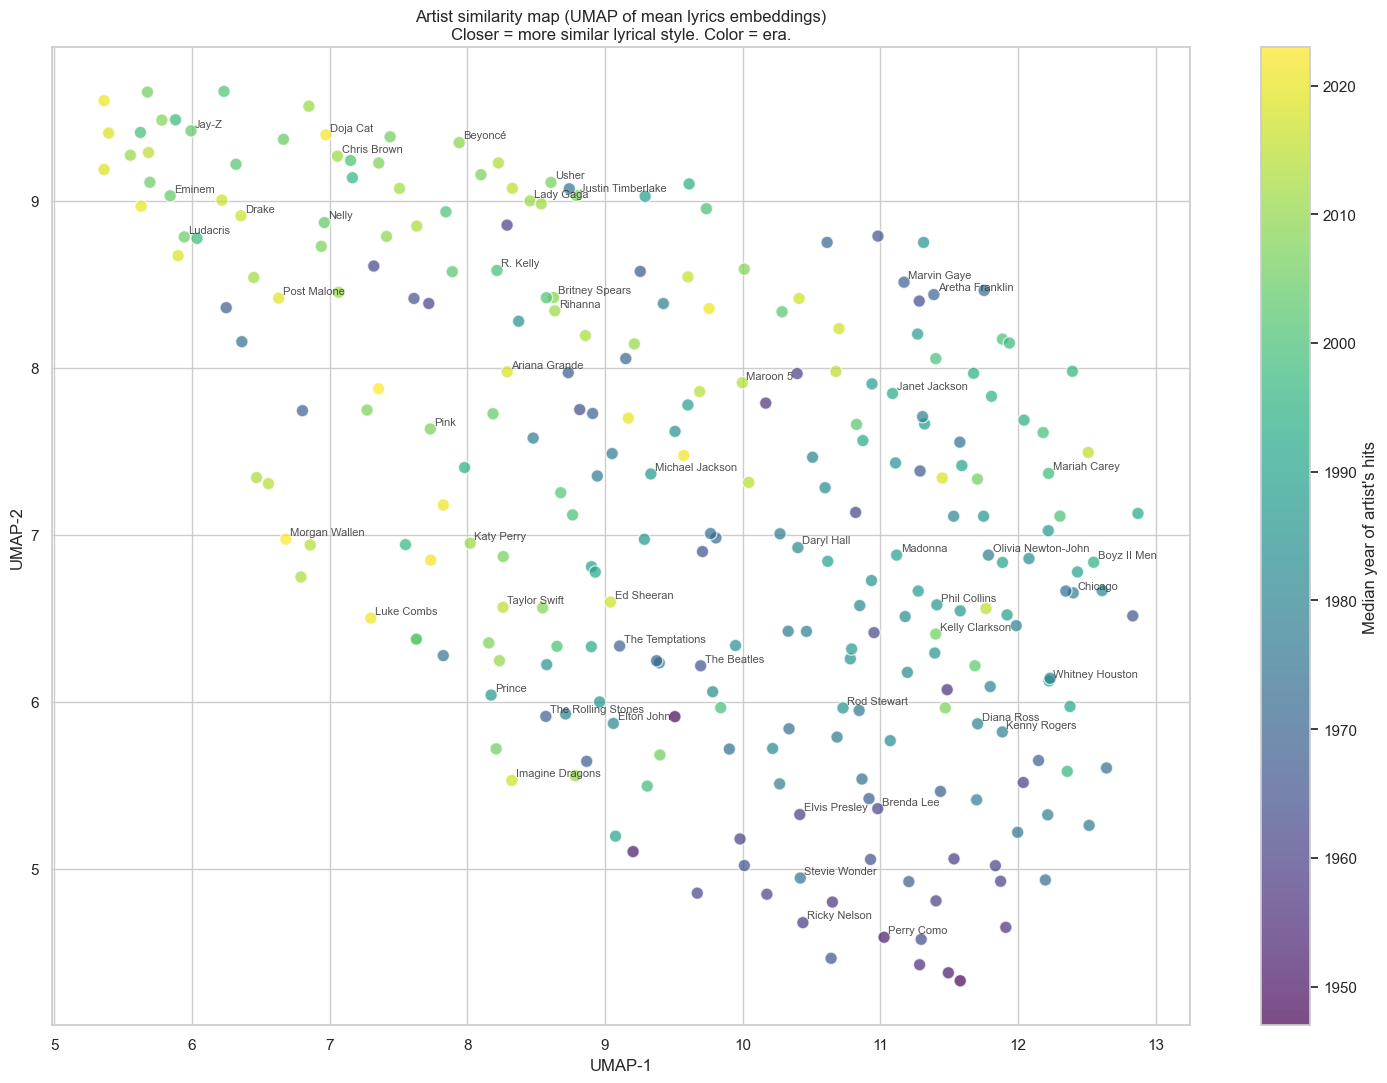

In [6]:
from umap import UMAP

# Load embeddings (computed in notebook 7) and align
embeddings = np.load(PROCESSED_DIR / "song_embeddings.npy")
df_en_order = df[df["language"] == "en"].reset_index(drop=True)
embedding_by_id = {sid: embeddings[i] 
                   for i, sid in enumerate(df_en_order["id"].values)}

# Compute mean embedding per artist (English-only songs)
artist_embeddings = {}
for artist in top_artists:
    artist_song_ids = df_top[df_top["primary_artist"] == artist]["id"].values
    embs = [embedding_by_id[sid] for sid in artist_song_ids if sid in embedding_by_id]
    if len(embs) >= 3:
        artist_embeddings[artist] = np.mean(embs, axis=0)

print(f"Artists with computable embeddings: {len(artist_embeddings)}")

# UMAP to 2D
artists_list = list(artist_embeddings.keys())
emb_matrix = np.array([artist_embeddings[a] for a in artists_list])

umap_2d = UMAP(n_neighbors=15, min_dist=0.3, metric="cosine", random_state=42)
coords = umap_2d.fit_transform(emb_matrix)

# Color by median year of each artist's hits
artist_median_year = np.array([
    df_top[df_top["primary_artist"] == a]["year"].median()
    for a in artists_list
])

fig, ax = plt.subplots(figsize=(15, 11))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=artist_median_year,
                      cmap="viridis", s=80, alpha=0.7, edgecolors="white")

# Label top-charting artists
artist_total_counts = {a: artist_counts[a] for a in artists_list}
top_50_to_label = sorted(artists_list, key=lambda a: -artist_total_counts[a])[:50]
for artist in top_50_to_label:
    i = artists_list.index(artist)
    ax.annotate(artist, (coords[i, 0], coords[i, 1]), 
                fontsize=8, alpha=0.8,
                xytext=(3, 3), textcoords="offset points")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Median year of artist's hits")
ax.set_title("Artist similarity map (UMAP of mean lyrics embeddings)\n"
             "Closer = more similar lyrical style. Color = era.")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
plt.tight_layout(); plt.show()

## Nearest stylistic neighbors

For a few well-known artists, find the most similar artists by lyrics embedding. Surprising similarities = interesting findings.

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute pairwise similarities
sims = cosine_similarity(emb_matrix)

# Look up neighbors for famous artists
spotlight = [
    "Drake", "Taylor Swift", "The Beatles", "Eminem", "Bruno Mars",
    "Madonna", "Michael Jackson", "Beyoncé", "Kanye West", "Frank Sinatra",
    "Elvis Presley", "The Weeknd", "Rihanna", "Mariah Carey", "Bob Dylan",
]

print("Nearest stylistic neighbors (by mean lyric embedding cosine similarity):\n")
for target in spotlight:
    if target not in artists_list:
        continue
    i = artists_list.index(target)
    neighbor_idx = sims[i].argsort()[::-1][1:8]  # skip self
    neighbors = [(artists_list[j], sims[i, j]) for j in neighbor_idx]
    print(f"  {target}:")
    for n, s in neighbors:
        print(f"    {s:.3f}  {n}")
    print()

Nearest stylistic neighbors (by mean lyric embedding cosine similarity):

  Drake:
    0.945  Puff Daddy
    0.937  Chris Brown
    0.933  Post Malone
    0.930  Nicki Minaj
    0.927  Lil Wayne
    0.924  Jay-Z
    0.916  Lil Baby

  Taylor Swift:
    0.935  Katy Perry
    0.923  Ed Sheeran
    0.918  Aerosmith
    0.917  Maroon 5
    0.915  Michael Jackson
    0.911  Prince
    0.911  Elton John

  The Beatles:
    0.928  Michael Jackson
    0.927  Madonna
    0.915  Whitney Houston
    0.913  Janet Jackson
    0.912  Fleetwood Mac
    0.910  Donna Summer
    0.908  Elvis Presley

  Eminem:
    0.900  Drake
    0.894  Jay-Z
    0.888  Nicki Minaj
    0.887  Post Malone
    0.885  Ludacris
    0.878  Puff Daddy
    0.876  Lil Wayne

  Bruno Mars:
    0.925  Beyoncé
    0.911  Meghan Trainor
    0.906  Maroon 5
    0.904  Chris Brown
    0.903  Katy Perry
    0.902  Rihanna
    0.897  Justin Bieber

  Madonna:
    0.952  Whitney Houston
    0.940  Mariah Carey
    0.940  Janet Jackson


## Save artist analysis

In [8]:
artist_scores.to_csv(PROCESSED_DIR / "artist_distinctiveness.csv")
print(f"Saved artist distinctiveness scores to artist_distinctiveness.csv")

Saved artist distinctiveness scores to artist_distinctiveness.csv
